In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
sys.path.append("simulations")

In [4]:
import polars as pl
import jax

from analysis import housemaze_model_data
from analysis import housemaze_user_data

# from analysis import data_loading
from analysis import housemaze_analysis
from nicewebrl import dataframe

# env, example_timestep = housemaze_model_data.load_env_and_example_timestep()

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


# Simulation data

In [5]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"

################
# Load model data
################
# %debug
model_df = housemaze_model_data.get_model_data(
  qlearning_path=f"{data_dir}/model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=*",
  sf_path=f"{data_dir}/model_data/usfa/save_data/usfa-big-10-search/sf_h=1024,num_=2,tota=40000000,exp=exp2/seed=*",
  dyna_path=f"{data_dir}/model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=*",
  search_path=f"{data_dir}/search_algos",
  overwrite_episodes=False,
  overwrite_df=False,
)

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:66: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype)


In [6]:
# model_df = model_df.rename({'went_to_junction': 'reuse'})

# Human data

In [7]:
from glob import glob

# ON COMPUTER
RESULTS_DIR = "/Users/wilka/git/research/"
USER_RESULTS_DIR = os.path.join(RESULTS_DIR, "results/human_dyna/user_data/exps")

human_data_pattern = "final*v2*"



files = f"{USER_RESULTS_DIR}/*{human_data_pattern}*.json"
# files = 'jaxemaze_data/*.json'
valid_files = list(set(glob(files)))
len(valid_files)

400

In [8]:
user_df = housemaze_user_data.get_human_data(
    valid_files,
    overwrite_episode_data=False,
    overwrite_episode_info=True,
    require_finished=False,
    # debug=True
)

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  pid = os.fork()
Failed to unpack record in /Users/wilka/git/research/results/human_dyna/user_data/exps/user=4238060579_name=jaxmaze_final-v2-r1-t0-start_debug=0.json: unpack(b) received extra data.
/Users/wilka/git/research/human-dyna-web/analysis/housemaze_user_data.py:711: RuntimeWarning: invalid value encountered in log
  return np.log(e.reaction_times + 1e-5)


Combining results:   0%|          | 0/400 [00:00<?, ?it/s]

In [20]:
len(user_df)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


28351

In [21]:
user_df.filter(manipulation=4).head()

index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,user,debug,exp_name,tell_reuse,reversal,optimal_length,success,path_length,termination,log_first_rt,first_rt,log_avg_rt,log_total_rt,total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,str,str,str,i64,str,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
0,"""big_m4_maze_long_blind_(F,T)""",0,"""big_m4_maze_long_blind__(F,T)_…","""See if faster off train path t…",4,0,1,false,31,0,3162296294,45,"""Female""","""3162296294""","""0""","""jaxmaze""",0,"""F,T""",20,1.0,20,1.0,-0.104239,0.901,-1.249783,-24.995661,6.35,-1.310075,-0.104239,-0.420056,-0.420056,-0.703177,-0.703177,0,null
1,"""big_m4_maze_long_blind_(F,T)""",0,"""big_m4_maze_long_blind__(F,T)_…","""See if faster off train path t…",4,1,2,false,31,0,3162296294,45,"""Female""","""3162296294""","""0""","""jaxmaze""",0,"""F,T""",25,1.0,25,1.0,0.964323,2.623,-1.079846,-26.996151,10.464999,-1.16502,0.964323,-0.360955,-0.360955,-1.207278,-1.126981,0,null
2,"""big_m4_maze_long_blind_(F,T)""",0,"""big_m4_maze_long_blind__(F,T)_…","""See if faster off train path t…",4,2,3,false,31,0,3162296294,45,"""Female""","""3162296294""","""0""","""jaxmaze""",0,"""F,T""",15,1.0,15,1.0,0.260832,1.298,-1.097017,-16.455259,5.702,-1.194007,0.260832,-0.616168,-0.616168,-0.66746,-0.66746,0,null
3,"""big_m4_maze_long_blind_(F,T)""",0,"""big_m4_maze_long_blind__(F,T)_…","""See if faster off train path t…",4,3,4,false,31,0,3162296294,45,"""Female""","""3162296294""","""0""","""jaxmaze""",0,"""F,T""",15,1.0,15,1.0,0.300852,1.351,-1.170535,-17.558022,5.317001,-1.275634,0.300852,-1.002366,-1.002366,-1.139403,-1.139403,0,null
4,"""big_m4_maze_long_blind_(F,T)""",0,"""big_m4_maze_long_blind__(F,T)_…","""See if faster off train path t…",4,4,5,false,31,0,3162296294,45,"""Female""","""3162296294""","""0""","""jaxmaze""",0,"""F,T""",22,1.0,22,1.0,0.181496,1.199,-1.232416,-27.113148,7.3,-1.299745,0.181496,-0.440041,-0.440041,-0.780864,-0.780864,0,null


# Analysis

In [23]:
# !pip install statsmodels

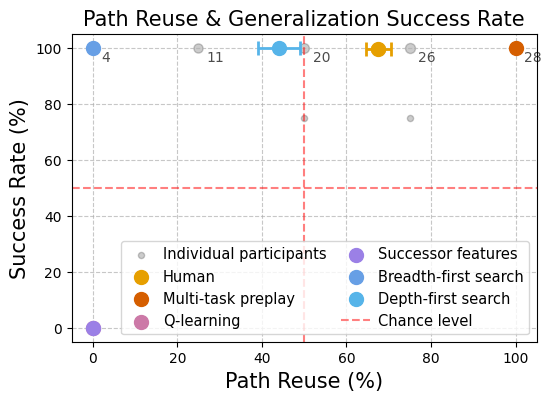

Filtered 0 rows with null success or reuse


Power levels:   0%|          | 0/3 [00:00<?, ?it/s]

Simulating data:   0%|          | 0/1 [00:00<?, ?it/s]

Simulating data:   0%|          | 0/1 [00:00<?, ?it/s]

Simulating data:   0%|          | 0/1 [00:00<?, ?it/s]

...

Simulating data:   0%|          | 0/1 [00:00<?, ?it/s]

Simulating data:   0%|          | 0/1 [00:00<?, ?it/s]

Simulating data:   0%|          | 0/1 [00:00<?, ?it/s]

Simulating data:   0%|          | 0/1 [00:00<?, ?it/s]

Saving results to <_io.TextIOWrapper name='/Users/wilka/git/research/results/human_dyna//housemaze_analysis_results_final/exp1_tell_reuse=1/stats.txt' mode='w' encoding='UTF-8'>.log_max_rt_reuse_1.pkl
n no_reuse: 63
n reuse: 87


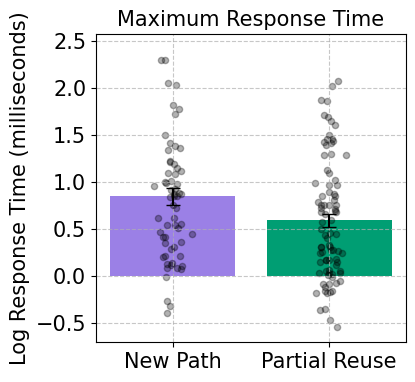

Experiment 1 Statistical Analysis


Analysis Results:
N = 91 participants (mean 4.0 trials per participant)
Mean reuse rate: 0.676 (SE: 0.030)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 2052.500
p = 0.000

Effect Size (r):
0.513

Required Sample Sizes:
Power 80%: N ≥ 7 participants
Power 90%: N ≥ 8 participants
Power 95%: N ≥ 10 participants

Reaction Time Analysis

log_max_rt
--------------------

Linear Mixed Effects Model Results:
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: RT       
No. Observations: 362     Method:             REML     
No. Groups:       91      Scale:              0.2187   
Min. group size:  3       Log-Likelihood:     -327.7152
Max. group size:  4       Converged:          Yes      
Mean group size:  4.0                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--

In [22]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_final/"
# %debug
housemaze_analysis.path_reuse_results(
  user_df,
  model_df,
  save_dir=save_dir,
  tell_reuse=1,
  display_figs=True,
  save_figs=True,
  n_simulations=1,
  verbosity=1,
)

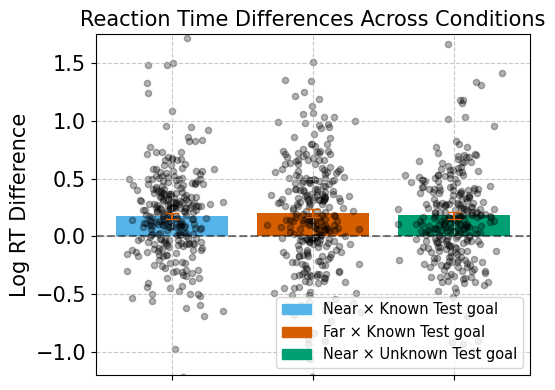

In [23]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.juncture_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  save_figs=True,
  display_figs=True,
)

In [57]:
data_dir = '/Users/wilka/git/research/results/human_dyna/'
save_dir = f'{data_dir}/analysis_results/'
housemaze_analysis.juncture_results(
    user_df,
    model_df,
    save_dir=save_dir,
    tell_reuse=0,
    display_figs=False,
    save_figs=True)

In [15]:
# data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"


# housemaze_analysis.experiment_2_results(
#   user_df,
#   model_df,
#   save_dir=save_dir,
#   tell_reuse=1,
#   save_figs=True,
#   verbosity=1,
# )
# # housemaze_analysis.experiment_2_results(
# #     user_df,
# #     model_df,
# #     save_dir=save_dir,
# #     tell_reuse=0,
# #     save_figs=True)

In [68]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.experiment_3_results(
  user_df,
  model_df,
  filter_columns=[],
  save_dir=save_dir,
  tell_reuse=1,
  save_figs=True,
  verbosity=1,
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Experiment 3 Statistical Analysis


log_first_rt:
N = 25 participants
Mean difference = 0.276 (SE: 0.118)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 215.000
p = 0.082

Effect Size (r):
0.278

Power Analysis:
Achieved power with current N=25: 0.834
Required sample sizes:
  80% power: N ≥ 21
  90% power: N ≥ 29
  95% power: N ≥ 36

log_avg_rt:
N = 25 participants
Mean difference = -0.015 (SE: 0.023)

Normality Test (Shapiro-Wilk):
p = 0.636 (Normal distribution)

Paired t-test:
statistic = -0.667
p = 0.744

Effect Size (Cohen's d):
-0.133

Power Analysis:
Achieved power with current N=25: 0.159
Required sample sizes:
  80% power: N ≥ 350
  90% power: N ≥ 484
  95% power: N ≥ 611



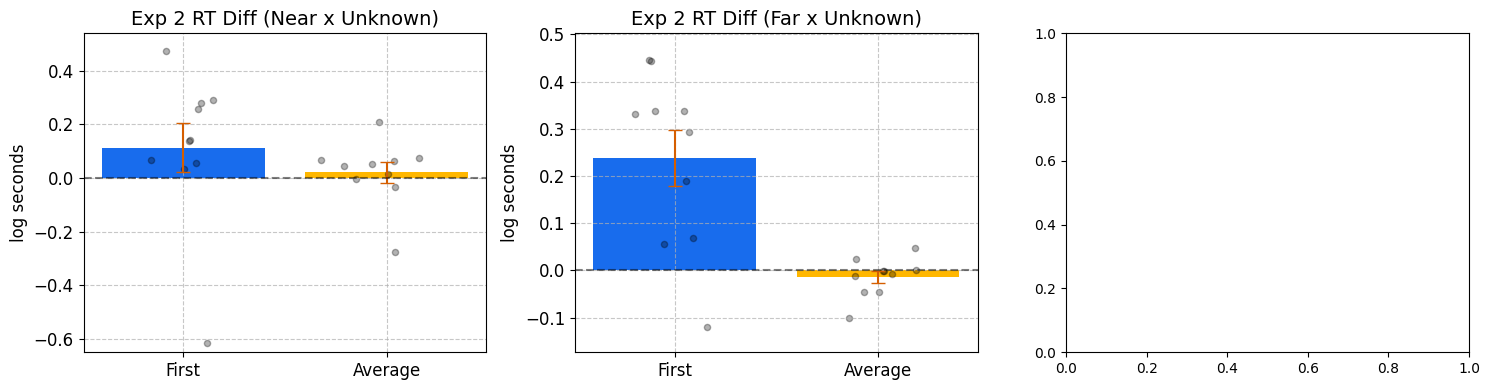

In [27]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.experiment_4_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  filter_columns=[],
  save_figs=True,
  display_figs=True,
  tell_reuse_options=[0],
)